# Lab 6 — The Optimizer Zoo: From SGD+Momentum to Adam

**Deep Learning · 80-minute PyTorch lab**

Every neural network you will ever train is steered by an **optimizer** — the rule
that turns a gradient into a parameter update. In this lab we open the hood on the
workhorse optimizers of modern deep learning and watch, literally, how each one
walks down a loss surface.

We follow **two evolutionary threads**:

| Thread | Idea | Optimizers |
|---|---|---|
| **Momentum** | *remember* past gradients to build speed & damp oscillation | SGD+Momentum → NAG |
| **Adaptive learning rates** | give *each parameter its own* step size | AdaGrad → RMSProp |
| **The fusion** | combine both | Adam |

### Learning Objectives
By the end of this lab you will be able to:
1. **Derive and implement** each optimizer's update rule *from scratch* in raw PyTorch tensors — with every math symbol matching a code variable.
2. **Explain the "why"** behind each innovation (why momentum, why per-parameter LR, why bias-correction).
3. **Diagnose behaviour visually** — recognise each optimizer's signature on a loss-surface contour and on a real training curve.

### Roadmap
- **Part A — The Toy Lab (build it):** derive the **three key** optimizers by hand — `SGD+Momentum`, `RMSProp`, `Adam` — read the other three as one-line variations, then race **all six** on a 2-parameter loss surface you can *see*.
- **Part B — The Real Lab (use it):** train an MLP on **FashionMNIST** and switch optimizers by changing **one line** with `torch.optim`.

> *Pacing (~75 min):* Part A ≈ 40 min · Part B + exercise ≈ 30 min · wrap-up ≈ 5 min.
> *Optional appendix cells at the end are marked "if time permits" — skip them live and revisit at home.*


## 0 · Setup & Reproducibility

> **Note.** Enable the GPU for Part B: **Runtime → Change runtime type → Hardware accelerator → T4 GPU**.
> Part A runs instantly on CPU; Part B trains several models and is *much* faster on GPU (~2 min vs ~15 min).


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# --- Reproducibility: fix the seed everywhere ---
torch.manual_seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- Hyperparameters you can throttle live ---
EPOCHS     = 5      # Lite: 5 epochs already separates the optimizers clearly; bump to 10 for smoother curves
BATCH_SIZE = 128

print(f"PyTorch {torch.__version__}")
print(f"Device : {DEVICE}")
if DEVICE == "cpu":
    print("Running on CPU. Part A is fine, but enable a GPU before Part B (see the note above).")
else:
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

PyTorch 2.11.0+cu128
Device : cuda
GPU    : Tesla T4


## Notation (used throughout this lab)

We use one consistent notation for **every** optimizer, and each math symbol maps to a code variable:

| Symbol | Meaning | Code |
|---|---|---|
| $w_t$ | weight (any parameter) at step $t$ | `w` |
| $w_{t+1}$ | the updated weight (next step) | returned `w` |
| $b$ | bias — same update rule as $w$ | `nn.Linear` bias |
| $\nabla w_t$ | gradient $\partial L / \partial w$ at $w_t$ | `grad_w` |
| $\eta$ | learning rate | `eta` (PyTorch: `lr`) |
| $m_t$ | first moment — running mean of gradients | `m` |
| $v_t$ | second moment — running mean of squared gradients | `v` |
| $\beta, \beta_1, \beta_2$ | decay rates for the moments | `beta`, `b1`, `b2` |
| $\varepsilon$ | numerical-stability constant | `eps` |

Every update below has the same shape:

$$ w_{t+1} = w_t - \eta \cdot \big(\text{something built from } \nabla w_t\big) $$


# Part A — The Toy Lab
## A.1 · Why plain gradient descent struggles: the *ravine*

Real loss surfaces are **ill-conditioned**: steep in some directions, nearly flat in others.
To see the problem in 2-D we use a quadratic bowl whose curvature is **20× stronger** along
`w[1]` than along `w[0]`:

$$ L(w) = \tfrac{1}{2}\left(c_0\, w_0^2 + c_1\, w_1^2\right),
\qquad (c_0,\ c_1) = (0.6,\ 12.0) $$

where $c_0, c_1$ are the per-axis **curvatures** (in code: the vector `CURV`). Because $c_1$ is
**20× larger** than $c_0$, the bowl is steep along $w_1$ and shallow along $w_0$ — an ill-conditioned
"ravine". The minimum is at the origin $(0,0)$. A single fixed learning rate faces a dilemma:
- **large enough** to make progress along the flat `w[0]` axis → it **overshoots and oscillates** along the steep `w[1]` axis;
- **small enough** to be stable on `w[1]` → it **crawls** along `w[0]`.

This tension — the "ravine" or "zig-zag" problem — is *exactly* what momentum and adaptive methods were invented to fix. Let's build the surface and the tooling.

In [ ]:
# ---------- The toy loss surface: an ill-conditioned quadratic "ravine" ----------
CURV    = torch.tensor([0.6, 12.0])   # (c0, c1): shallow along w[0], steep along w[1]
W_START = [-4.5, 4.5]                  # Starting point for optimizers
STEPS   = 60                           # Optimization steps

def toy_loss(w):
    # Works for both 1D PyTorch tensors AND 2D NumPy meshgrids for plotting!
    return 0.5 * (CURV[0] * w[0]**2 + CURV[1] * w[1]**2)

def grad_at(loss_fn, point):
    p = torch.tensor(point, dtype=torch.float32, requires_grad=True)
    loss_fn(p).backward()
    return p.grad

def run_on_surface(optimizer, loss_fn=toy_loss, start=W_START, steps=STEPS):
    w = torch.tensor(start, dtype=torch.float32)
    path = [w.clone()]
    for t in range(1, steps + 1):
        w = optimizer.step(w, loss_fn, t)
        path.append(w.clone())
    return torch.stack(path)

def plot_paths(paths, title, rng=(-5, 5)):
    X, Y = np.meshgrid(np.linspace(*rng, 250), np.linspace(*rng, 250))
    Z = toy_loss([X, Y])  # Evaluates directly using the unified loss function!

    plt.figure(figsize=(7.5, 6.5))
    plt.contour(X, Y, Z, levels=30, cmap="viridis", alpha=0.55)
    for name, path in paths.items():
        plt.plot(path[:, 0], path[:, 1], marker="o", ms=2.5, lw=1.6, label=name)
    plt.plot(0, 0, marker="*", color="red", ms=22, label="minimum", zorder=5)
    plt.title(title); plt.xlabel("w[0] (shallow axis)"); plt.ylabel("w[1] (steep axis)")
    plt.legend(loc="upper right"); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

print("Toy surface ready. Minimum at (0,0); starting at", W_START)

Toy surface ready. Minimum at (0,0); starting at [-4.5, 4.5]


## A.2 · Thread 1 — Momentum

> **Derive with me:** `SGD+Momentum`.  **Read-only variations:** `PlainSGD` (baseline) and `NAG` (same code, gradient taken at a look-ahead point).

### Baseline: plain SGD
$$ w_{t+1} = w_t - \eta\, \nabla w_t $$
where $\nabla w_t = \dfrac{\partial L}{\partial w}$ is the current gradient. Simple, but it zig-zags in the ravine.

### SGD + Momentum
Instead of stepping along the raw gradient, we keep a **first moment** $m$ (a *velocity*) — an
exponentially-weighted running sum of past gradients — and step along *that*:
$$ m_t = \beta\, m_{t-1} + \nabla w_t \qquad w_{t+1} = w_t - \eta\, m_t $$
Gradients that keep pointing the same way (the flat `w[0]` axis) **accumulate into speed**;
gradients that flip sign every step (the steep `w[1]` axis) **cancel out**. Momentum `beta`
is typically `0.9` — think "keep 90% of yesterday's velocity."

### Nesterov Accelerated Gradient (NAG)
NAG adds *foresight*: before measuring the gradient, it first takes a peek at where the
momentum is about to carry it (the **look-ahead** point $\tilde w$), and measures the slope **there**:
$$ \tilde w = w_t - \eta\,\beta\, m_{t-1}
\qquad m_t = \beta\, m_{t-1} + \nabla \tilde w
\qquad w_{t+1} = w_t - \eta\, m_t $$
where $\nabla\tilde w = \dfrac{\partial L}{\partial w}$ evaluated at $\tilde w$. This "look before you
leap" correction lets NAG **brake earlier** and overshoot less than plain momentum.

/tmp/ipykernel_1158/229294772.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p = torch.tensor(point, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_1158/229294772.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 0.5 * (CURV[0] * w[0]**2 + CURV[1] * w[1]**2)


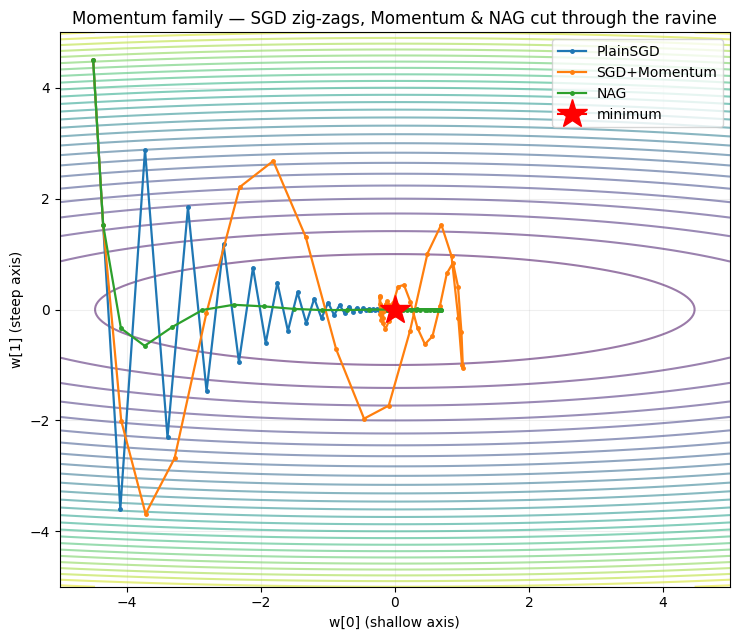

In [ ]:
# ---------- Momentum family, implemented from scratch ----------
class PlainSGD:
    def __init__(self, eta):
        self.eta = eta
    def step(self, w, loss_fn, t):
        grad_w = grad_at(loss_fn, w)                  # grad_w = ∇w_t = ∂L/∂w
        return w - self.eta * grad_w                  # w_{t+1} = w_t - eta*grad_w

class SGDMomentum:
    def __init__(self, eta, beta=0.9):
        self.eta, self.beta = eta, beta
        self.m = None                                 # first moment (velocity)
    def step(self, w, loss_fn, t):
        grad_w = grad_at(loss_fn, w)
        if self.m is None: self.m = torch.zeros_like(w)
        self.m = self.beta * self.m + grad_w          # m_t = beta*m_{t-1} + grad_w
        return w - self.eta * self.m                  # w_{t+1} = w_t - eta*m_t

class NAG:
    def __init__(self, eta, beta=0.9):
        self.eta, self.beta = eta, beta
        self.m = None
    def step(self, w, loss_fn, t):
        if self.m is None: self.m = torch.zeros_like(w)
        w_look = w - self.eta * self.beta * self.m    # look-ahead point  w~
        grad_w = grad_at(loss_fn, w_look)             # gradient measured AT the look-ahead
        self.m = self.beta * self.m + grad_w
        return w - self.eta * self.m

paths = {
    "PlainSGD"     : run_on_surface(PlainSGD(eta=0.15)),
    "SGD+Momentum" : run_on_surface(SGDMomentum(eta=0.055, beta=0.85)),
    "NAG"          : run_on_surface(NAG(eta=0.055, beta=0.85)),
}
plot_paths(paths, "Momentum family — SGD zig-zags, Momentum & NAG cut through the ravine")

**What to notice **
- **PlainSGD** (blue) visibly **zig-zags** across the steep `w[1]` axis while crawling along `w[0]`.
- **SGD+Momentum** builds speed along the flat direction and damps the vertical oscillation — but note it may **overshoot** slightly past the minimum before settling.
- **NAG**'s look-ahead makes its path a touch **tighter** — it anticipates the overshoot and brakes sooner.

## A.3 · Thread 2 — Adaptive learning rates

> **Derive with me:** `RMSProp`.  **Read-only:** `AdaGrad` — build it just enough to *see the flaw* RMSProp fixes.

Momentum uses **one** learning rate for all parameters. But what if each parameter needs a
*different* step size? Adaptive methods scale the step of each coordinate by its own gradient history.

### AdaGrad
Accumulate the **squared** gradients into the second moment $v$ and divide the step by its square root:
$$ v_t = v_{t-1} + (\nabla w_t)^2 \qquad
   w_{t+1} = w_t - \frac{\eta}{\sqrt{v_t}+\varepsilon}\; \nabla w_t $$
Parameters with large past gradients (the steep axis) get **small** steps; rarely-updated
parameters get **large** steps. **Problem:** $v_t$ only ever *grows*, so the effective step
size **decays toward zero** — AdaGrad can **stall** before reaching the minimum.

### RMSProp
Same idea, but replace the ever-growing sum with an **exponentially-weighted moving average**,
so old gradients are forgotten and the denominator stops exploding:
$$ v_t = \beta\, v_{t-1} + (1-\beta)\, (\nabla w_t)^2 \qquad
   w_{t+1} = w_t - \frac{\eta}{\sqrt{v_t}+\varepsilon}\; \nabla w_t $$
This one change keeps the effective learning rate **stable** and fixes AdaGrad's stalling.

/tmp/ipykernel_1158/229294772.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p = torch.tensor(point, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_1158/229294772.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 0.5 * (CURV[0] * w[0]**2 + CURV[1] * w[1]**2)


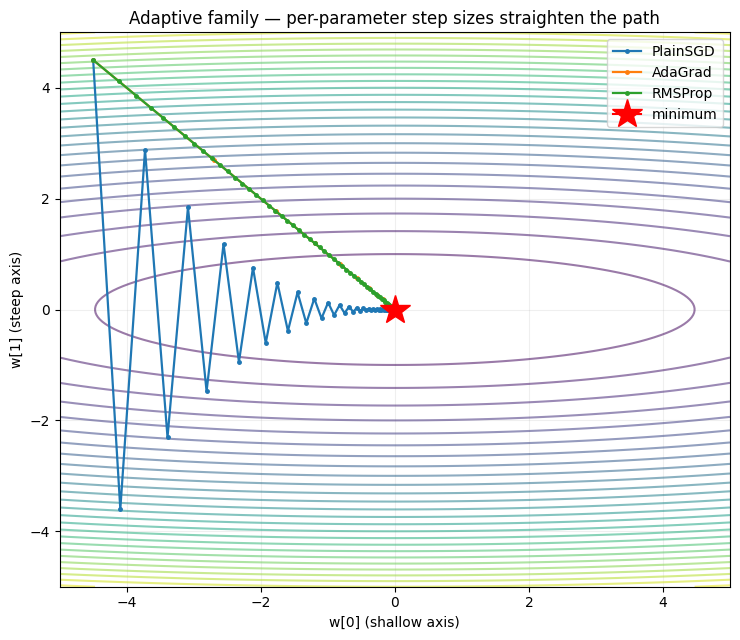

In [ ]:
# ---------- Adaptive family, implemented from scratch ----------
class AdaGrad:
    def __init__(self, eta, eps=1e-8):
        self.eta, self.eps = eta, eps
        self.v = None                                 # second moment: SUM of squared grads
    def step(self, w, loss_fn, t):
        grad_w = grad_at(loss_fn, w)
        if self.v is None: self.v = torch.zeros_like(w)
        self.v = self.v + grad_w**2                    # v_t = v_{t-1} + (grad_w)^2
        return w - self.eta * grad_w / (self.v.sqrt() + self.eps)

class RMSProp:
    def __init__(self, eta, beta=0.9, eps=1e-8):
        self.eta, self.beta, self.eps = eta, beta, eps
        self.v = None                                 # second moment: EWMA of squared grads
    def step(self, w, loss_fn, t):
        grad_w = grad_at(loss_fn, w)
        if self.v is None: self.v = torch.zeros_like(w)
        self.v = self.beta * self.v + (1 - self.beta) * grad_w**2   # v_t
        return w - self.eta * grad_w / (self.v.sqrt() + self.eps)

paths = {
    "PlainSGD" : run_on_surface(PlainSGD(eta=0.15)),
    "AdaGrad"  : run_on_surface(AdaGrad(eta=1.8)),
    "RMSProp"  : run_on_surface(RMSProp(eta=0.12, beta=0.9)),
}
plot_paths(paths, "Adaptive family — per-parameter step sizes straighten the path")

**What to notice ** Adaptive methods take a much **straighter** route: by shrinking the
step along the steep `w[1]` axis and keeping it large along the flat `w[0]` axis, they mostly
**avoid the zig-zag** without needing momentum at all. Next we'll *quantify* AdaGrad's stalling.

## A.4 · The fusion — Adam

> **Derive with me:** `Adam` — it fuses both threads (momentum + adaptive learning rates).

### Adam = Momentum + RMSProp + bias-correction
Adam keeps **both** the first moment $m$ (a running mean of gradients, like momentum) **and** the
second moment $v$ (a running mean of squared gradients, like RMSProp):
$$ m_t = \beta_1 m_{t-1} + (1-\beta_1)\,\nabla w_t \qquad
   v_t = \beta_2 v_{t-1} + (1-\beta_2)\,(\nabla w_t)^2 $$
Because $m$ and $v$ start at **zero**, they are biased toward zero in the first few steps, so
Adam applies **bias-correction** before using them:
$$ \hat m_t = \frac{m_t}{1-\beta_1^{\,t}} \qquad \hat v_t = \frac{v_t}{1-\beta_2^{\,t}} \qquad
   w_{t+1} = w_t - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon} $$
Defaults `b1=0.9` ($\beta_1$), `b2=0.999` ($\beta_2$), `eps=1e-8` ($\varepsilon$). Adam is the "just works" default of deep learning — it inherits momentum's acceleration **and** the adaptive per-parameter step size, then stabilises the early steps with bias-correction.

/tmp/ipykernel_1158/229294772.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p = torch.tensor(point, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_1158/229294772.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 0.5 * (CURV[0] * w[0]**2 + CURV[1] * w[1]**2)


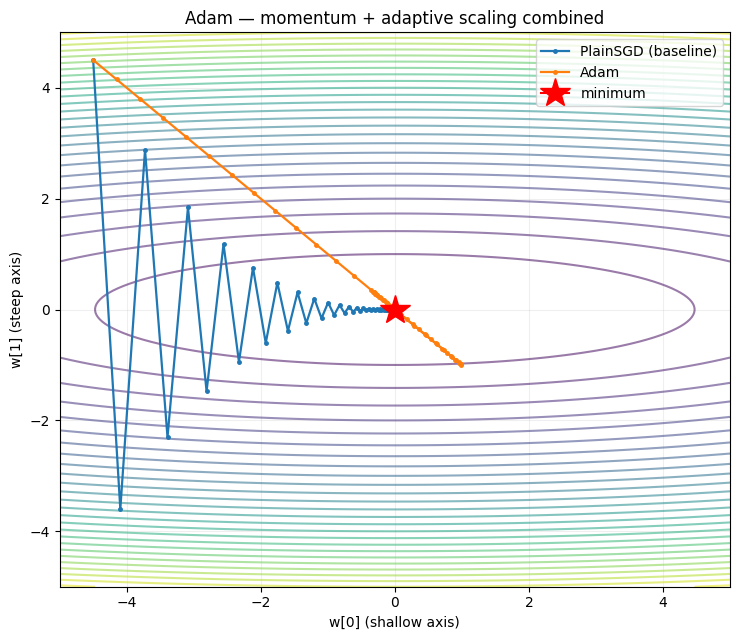

In [ ]:
# ---------- Adam family, implemented from scratch ----------
class Adam:
    def __init__(self, eta, b1=0.9, b2=0.999, eps=1e-8):
        self.eta, self.b1, self.b2, self.eps = eta, b1, b2, eps
        self.m = None; self.v = None
    def step(self, w, loss_fn, t):
        grad_w = grad_at(loss_fn, w)
        if self.m is None: self.m = torch.zeros_like(w); self.v = torch.zeros_like(w)
        self.m = self.b1 * self.m + (1 - self.b1) * grad_w         # first moment  (momentum)
        self.v = self.b2 * self.v + (1 - self.b2) * grad_w**2      # second moment (RMSProp)
        m_hat = self.m / (1 - self.b1 ** t)                        # bias-correction
        v_hat = self.v / (1 - self.b2 ** t)
        return w - self.eta * m_hat / (v_hat.sqrt() + self.eps)    # w_{t+1}

paths = {
    "PlainSGD (baseline)" : run_on_surface(PlainSGD(eta=0.15)),
    "Adam"                : run_on_surface(Adam(eta=0.35)),
}
plot_paths(paths, "Adam — momentum + adaptive scaling combined")

## A.5 · The Grand Race
All six optimizers, same start, same surface. This single plot is the whole story of Part A.

/tmp/ipykernel_1158/229294772.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p = torch.tensor(point, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_1158/229294772.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 0.5 * (CURV[0] * w[0]**2 + CURV[1] * w[1]**2)


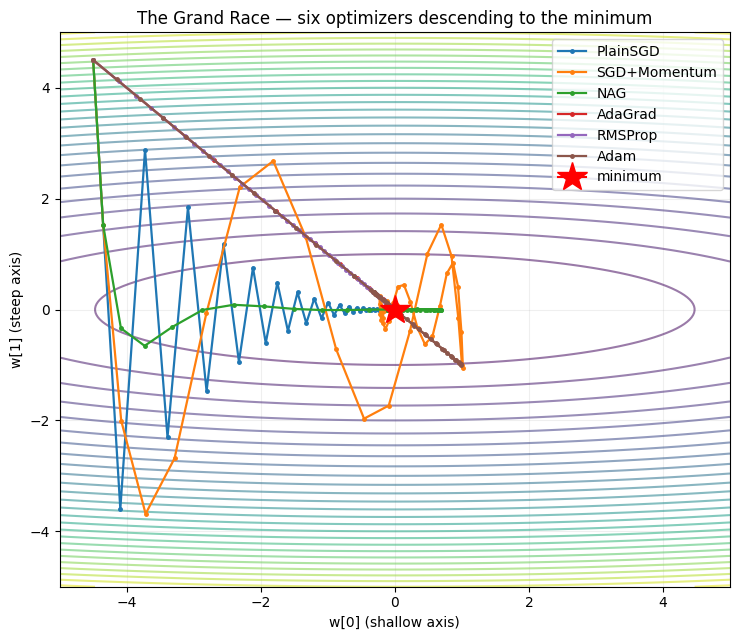

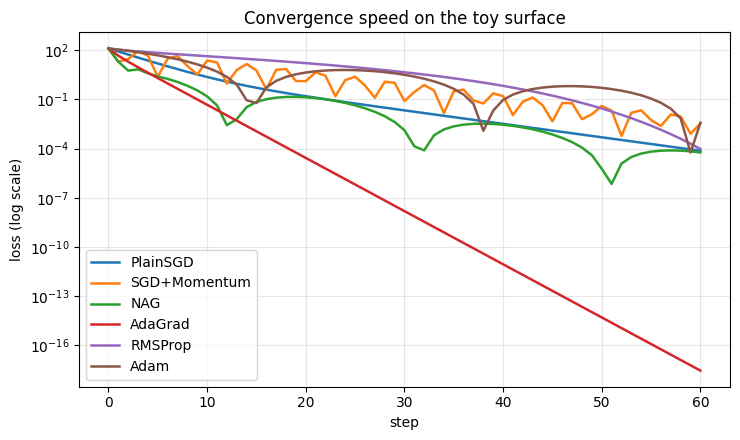

In [ ]:
all_paths = {
    "PlainSGD"     : run_on_surface(PlainSGD(eta=0.15)),
    "SGD+Momentum" : run_on_surface(SGDMomentum(eta=0.055, beta=0.85)),
    "NAG"          : run_on_surface(NAG(eta=0.055, beta=0.85)),
    "AdaGrad"      : run_on_surface(AdaGrad(eta=1.8)),
    "RMSProp"      : run_on_surface(RMSProp(eta=0.12, beta=0.9)),
    "Adam"         : run_on_surface(Adam(eta=0.35)),
}
plot_paths(all_paths, "The Grand Race — six optimizers descending to the minimum")

# Loss-vs-step for the same race (log scale makes the differences obvious)
plt.figure(figsize=(7.5, 4.5))
for name, path in all_paths.items():
    losses = [toy_loss(w).item() for w in path]
    plt.plot(losses, label=name, lw=1.8)
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("loss (log scale)")
plt.title("Convergence speed on the toy surface"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Discussion **
- Plain SGD is the slowest and noisiest — it pays for the ravine with zig-zag.
- Momentum/NAG accelerate but can overshoot.
- Adaptive & Adam-family methods take direct, smooth paths — which is exactly why Adam is the
  default first choice on messy real-world losses. Now let's confirm this on **real data**.

# Part B — The Real Lab
## B.1 · FashionMNIST + a small MLP

Enough toys. We now train a real classifier on **FashionMNIST** (70,000 grayscale 28×28 images,
10 clothing classes) and let *you* swap optimizers with a **one-line change** using `torch.optim`.

We keep the model small (an MLP: `784 → 128 → 10`) so all six optimizers finish quickly.
Each layer computes $\,h = \text{ReLU}(W_1 x + b_1)\,$ then logits $= W_2 h + b_2$. The optimizer
updates **both** the weights $W$ **and** the biases $b$ — using the exact same update rule
$w_{t+1} = w_t - \eta(\dots)$ you derived in Part A (here $w$ stands for any of $W_1,b_1,W_2,b_2$).

> **Note.** If this cell is slow, the GPU isn't enabled: **Runtime → Change runtime type → T4 GPU**, then re-run from the top.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# FashionMNIST ships with torchvision and downloads automatically (self-contained in Colab).
transform = transforms.Compose([
    transforms.ToTensor(),                       # [1,28,28] in [0,1]
    transforms.Normalize((0.2860,), (0.3530,)),  # dataset mean/std
])

train_ds = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=512,        shuffle=False)

CLASSES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print(f"Train: {len(train_ds)}  Test: {len(test_ds)}  Batch size: {BATCH_SIZE}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.3MB/s]

Train: 60000  Test: 10000  Batch size: 128


### A look at the data
Before training, let's see what we are actually classifying — 24 random training images with their labels.

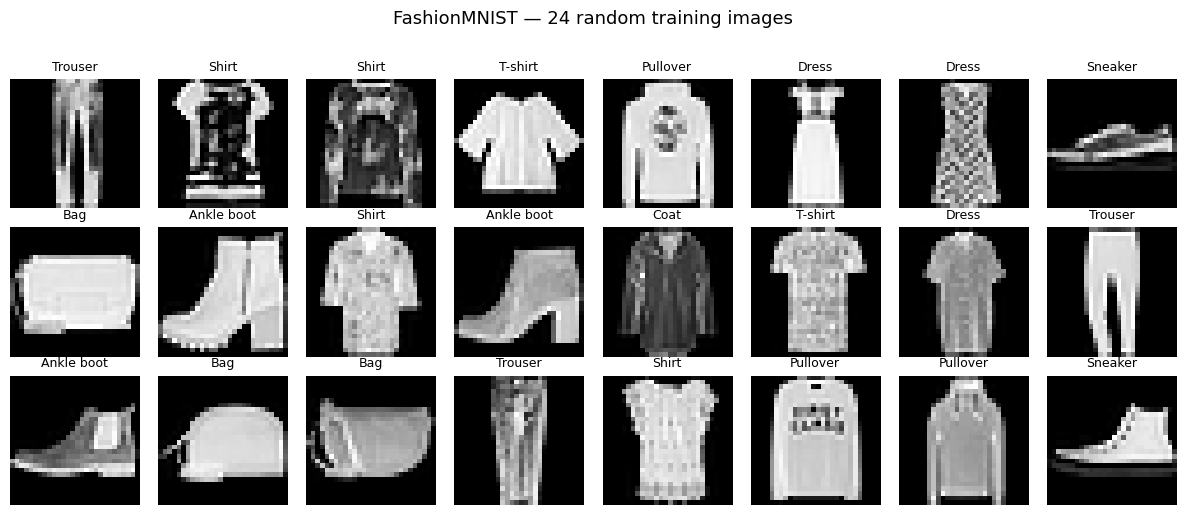

  T-shirt     : 6000
  Trouser     : 6000
  Pullover    : 6000
  Dress       : 6000
  Coat        : 6000
  Sandal      : 6000
  Shirt       : 6000
  Sneaker     : 6000
  Bag         : 6000
  Ankle boot  : 6000


In [ ]:
# ---------- Preview FashionMNIST ----------
MEAN, STD = 0.2860, 0.3530                          # the values we normalized with

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for ax in axes.flat:
    idx = np.random.randint(len(train_ds))
    img, label = train_ds[idx]                      # img: [1,28,28] (normalized), label: int
    img = img.squeeze() * STD + MEAN                # de-normalize back to [0,1] for display -> [28,28]
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASSES[label], fontsize=9)
    ax.axis("off")
plt.suptitle("FashionMNIST — 24 random training images", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# Class balance: how many images per class?
counts = torch.bincount(train_ds.targets)
for name, c in zip(CLASSES, counts.tolist()):
    print(f"  {name:12s}: {c}")

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                 # [B,1,28,28] -> [B,784]
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, 10),           # -> [B,10] logits
        )
    def forward(self, x):
        return self.net(x)                # [B,10]

def train_model(optimizer_fn, epochs=EPOCHS, verbose=True):
    '''Re-seed, build a fresh MLP, train with the given optimizer, return (model, history).
    optimizer_fn: a function  params -> torch.optim.Optimizer  (this is the ONE line you change).'''
    torch.manual_seed(42)                              # identical init for every optimizer -> fair race
    model = MLP().to(DEVICE)
    optimizer = optimizer_fn(model.parameters())
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train(); running, seen = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)      # [B,1,28,28], [B]
            optimizer.zero_grad()
            logits = model(xb)                         # [B,10]
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0); seen += xb.size(0)

        model.eval(); correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total   += yb.size(0)
        history["train_loss"].append(running / seen)
        history["test_acc"].append(correct / total)
    if verbose:
        print(f"    final train_loss={history['train_loss'][-1]:.4f}  test_acc={history['test_acc'][-1]:.4f}")
    return model, history

## B.2 · From our hand-written classes to `torch.optim`

In Part A we built every optimizer by hand. In practice PyTorch ships all of them in
`torch.optim`, so you never write the update rule again — you just pick a class. Here is the
map from *our* from-scratch classes to the library. **Note:** PyTorch's `lr=` argument is exactly
our learning rate $\eta$.

| Our Part-A class | `torch.optim` equivalent |
|---|---|
| `PlainSGD` | `torch.optim.SGD(params, lr)` |
| `SGDMomentum` | `torch.optim.SGD(params, lr, momentum=0.9)` |
| `NAG` | `torch.optim.SGD(params, lr, momentum=0.9, nesterov=True)` |
| `AdaGrad` | `torch.optim.Adagrad(params, lr)` |
| `RMSProp` | `torch.optim.RMSprop(params, lr)` |
| `Adam` | `torch.optim.Adam(params, lr)` |

**Note the key idea:** there is **no** separate `Momentum` or `Nesterov` class — **`torch.optim.SGD`
is one class that covers plain SGD, Momentum, and NAG**, switched on by its `momentum` and
`nesterov` arguments. Set `momentum=0` (the default) → plain SGD; set `momentum=0.9` → the
`SGDMomentum` you built; add `nesterov=True` → your `NAG`. Same math you implemented, now one line.

### Instructor demo — the one-line idea
Every optimizer plugs into the **same** training loop; the **only** line that changes is the
`torch.optim.…` call. Watch:

In [ ]:
print("Instructor demo — AdaGrad")
adagrad_fn = lambda params: torch.optim.Adagrad(params, lr=0.01)   # <-- THE one line
_, hist_adagrad = train_model(adagrad_fn)

Instructor demo — AdaGrad
    final train_loss=0.3129  test_acc=0.8714


## B.3 · Student Exercise — race the optimizers

Your job: fill in the **two `None` entries** below so each builds the right `torch.optim`
optimizer. Change **only the one line** per optimizer — the training loop never changes.
`Adagrad` is done for you as a template.

**Hints (PyTorch API):**
- SGD + Momentum → `torch.optim.SGD(params, lr=0.05, momentum=0.9)`
- Adam → `torch.optim.Adam(params, lr=0.001)`

**Optional stretch** (uncomment if you have time): `NAG` = SGD with `nesterov=True`, and `RMSprop`.

Fill in the dictionary, run the race, then read the plots that follow.

In [ ]:
# TODO: replace each `None` with a lambda that returns the correct torch.optim optimizer.
# The Adagrad entry is done for you as a template.
optimizers = {
    "Adagrad"      : lambda p: torch.optim.Adagrad(p, lr=0.01),   # DONE (template)
    "SGD+Momentum" : None,   # TODO: torch.optim.SGD(..., momentum=0.9)
    "Adam"         : None,   # TODO: torch.optim.Adam(...)

    # ---- Optional stretch: uncomment and fill in if time permits ----
    # "NAG"        : None,   # torch.optim.SGD(..., momentum=0.9, nesterov=True)
    # "RMSprop"    : None,   # torch.optim.RMSprop(...)
}

histories = {}
for name, fn in optimizers.items():
    if fn is None:
        print(f"[skip] {name}: not implemented yet — fill it in above."); continue
    print(f"Training with {name} ...")
    _, histories[name] = train_model(fn)

print(f"\nTrained {len(histories)}/6 optimizers.")

Training with Adagrad ...
    final train_loss=0.3129  test_acc=0.8714
[skip] SGD+Momentum: not implemented yet — fill it in above.
[skip] Adam: not implemented yet — fill it in above.

Trained 1/6 optimizers.


<details>
<summary><b>Click to reveal solution</b></summary>

```python
optimizers = {
    "Adagrad"      : lambda p: torch.optim.Adagrad(p, lr=0.01),
    "SGD+Momentum" : lambda p: torch.optim.SGD(p,     lr=0.05, momentum=0.9),
    "Adam"         : lambda p: torch.optim.Adam(p,    lr=0.001),

    # Optional stretch:
    "NAG"          : lambda p: torch.optim.SGD(p,     lr=0.05, momentum=0.9, nesterov=True),
    "RMSprop"      : lambda p: torch.optim.RMSprop(p, lr=0.001),
}

histories = {}
for name, fn in optimizers.items():
    if fn is None:
        continue
    print(f"Training with {name} ...")
    _, histories[name] = train_model(fn)
```

**Why these learning rates?** Adam-family methods use a small $\eta \approx 10^{-3}$ because their
adaptive scaling already normalises the step; SGD needs a larger $\eta \approx 0.05$ plus momentum
to move at a comparable pace. These are the community-standard defaults — a great starting point for any project.
</details>

## B.4 · Read the race — convergence & accuracy

Run the cells below (they use whatever you trained in `histories`).

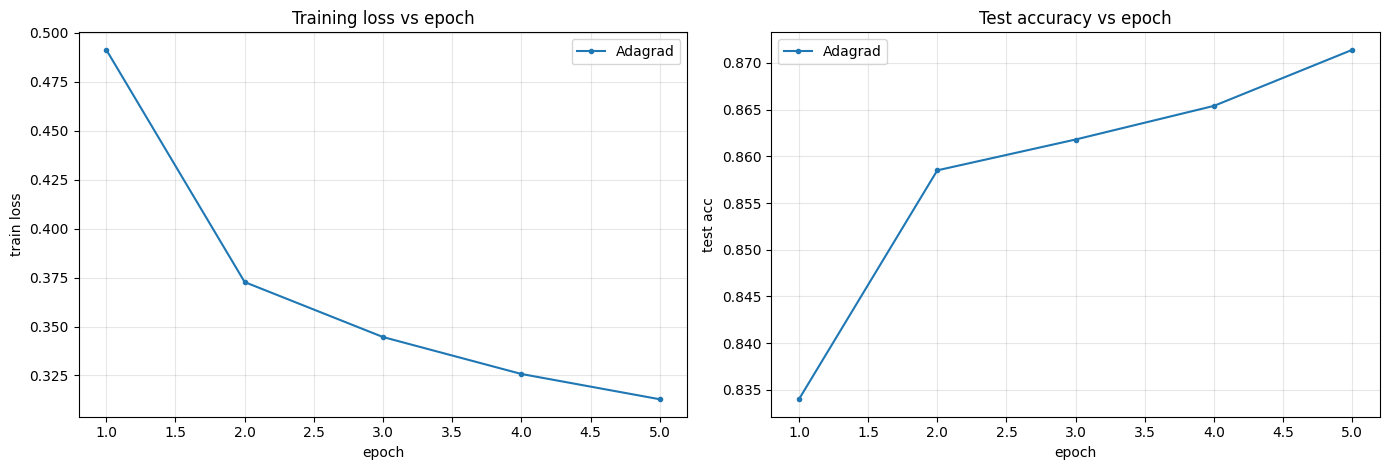

In [ ]:
if not histories:
    print("No optimizers trained yet — complete the exercise above first!")
else:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
    for name, h in histories.items():
        ax[0].plot(range(1, len(h["train_loss"]) + 1), h["train_loss"], marker="o", ms=3, label=name)
        ax[1].plot(range(1, len(h["test_acc"]) + 1),  h["test_acc"],   marker="o", ms=3, label=name)
    ax[0].set_title("Training loss vs epoch"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss")
    ax[0].grid(alpha=0.3); ax[0].legend()
    ax[1].set_title("Test accuracy vs epoch"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("test acc")
    ax[1].grid(alpha=0.3); ax[1].legend()
    plt.tight_layout(); plt.show()

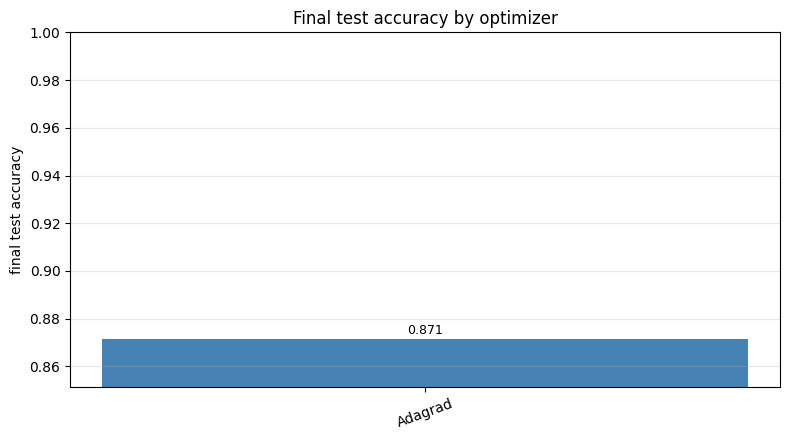

In [ ]:
if histories:
    names = list(histories.keys())
    final_acc = [histories[n]["test_acc"][-1] for n in names]
    plt.figure(figsize=(8, 4.5))
    bars = plt.bar(names, final_acc, color="steelblue")
    plt.ylim(min(final_acc) - 0.02, 1.0)
    plt.ylabel("final test accuracy"); plt.title("Final test accuracy by optimizer")
    for b, a in zip(bars, final_acc):
        plt.text(b.get_x() + b.get_width() / 2, a + 0.002, f"{a:.3f}", ha="center", fontsize=9)
    plt.xticks(rotation=20); plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

# Wrap-up — Which optimizer, when?

| Optimizer | Core idea | Reach for it when… |
|---|---|---|
| **SGD** | raw gradient step | you want a simple, well-understood baseline |
| **SGD + Momentum** | velocity damps oscillation | training CNNs / vision; often best *final* accuracy with tuning |
| **NAG** | look-ahead gradient | you want momentum with slightly less overshoot |
| **AdaGrad** | per-param LR, accumulate $(\nabla w)^2$ | sparse features (NLP); beware LR decaying to zero |
| **RMSProp** | EWMA of $(\nabla w)^2$ (fixes AdaGrad) | RNNs / non-stationary objectives |
| **Adam** | momentum + RMSProp + bias-correction | your **default first try** — robust, fast, low-tuning |

### Key takeaways
1. **Momentum** attacks *oscillation* (a direction problem); **adaptive LR** attacks *per-parameter scale* (a step-size problem). **Adam does both.**
2. **Bias-correction** matters only for the first handful of steps but keeps Adam stable early.
3. When in doubt: **start with Adam**, then, if you have time to tune, try **SGD+Momentum** for a possible accuracy edge.

### References
- Andrew Ng — *Deep Learning Specialization, Course 2* (EWMA & bias-correction intuition)
- Stanford **CS231n** — optimizer trajectory visualizations & the ravine intuition
- **d2l.ai**, Ch. 12 *Optimization* (math-to-code for momentum, AdaGrad, RMSProp, Adam)
- **CampusX** DL playlist — step-by-step PyTorch optimizer walkthroughs
- Kingma & Ba (2015) *Adam: A Method for Stochastic Optimization*

> **Stretch challenge:** re-run the toy **Grand Race** starting from a *different* point (e.g. `W_START=[4.0,-3.0]`) or on the harder **Beale** function — do the rankings change? Which optimizer is most robust to the starting point?
